In [1]:
!git clone https://github.com/Erdos-Projects/spring-2026-deep-learning-fragmented-id-resolution

Cloning into 'spring-2026-deep-learning-fragmented-id-resolution'...
remote: Enumerating objects: 332, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 332 (delta 72), reused 135 (delta 44), pack-reused 156 (from 1)
Receiving objects: 100% (332/332), 16.57 MiB | 8.87 MiB/s, done.
Resolving deltas: 100% (102/102), done.


In [2]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


In [3]:
%cd /content/spring-2026-deep-learning-fragmented-id-resolution
!git checkout Arpith

/content/spring-2026-deep-learning-fragmented-id-resolution
Updating files: 100% (30/30), done.
Branch 'Arpith' set up to track remote branch 'Arpith' from 'origin'.
Switched to a new branch 'Arpith'


In [10]:
%cd /content/spring-2026-deep-learning-fragmented-id-resolution/data/splits

/content/spring-2026-deep-learning-fragmented-id-resolution/data/splits


In [13]:
from os import dup
import pandas as pd
import numpy as np

# Read the TSV files into the DataFrame
#Data Source Hasso Plattner Institut
# NDPL - Non-duplicates
# DPL - Duplicates
# ncvoters - a snap shot of the snapshot: VR_Snapshot_20181106
train_voters = pd.read_csv('Naive/train_voters.csv')
val_voters = pd.read_csv('Naive/val_voters.csv')
test_voters = pd.read_csv('Naive/test_voters.csv')

dup_train = pd.read_csv('Naive/naive_dup_train.csv')
ndup_train = pd.read_csv('Naive/naive_ndup_train.csv')

dup_val = pd.read_csv('Naive/naive_dup_val.csv')
ndup_val = pd.read_csv('Naive/naive_ndup_val.csv')

dup_test = pd.read_csv('Naive/naive_dup_test.csv')
ndup_test = pd.read_csv('Naive/naive_ndup_test.csv')

/tmp/ipykernel_151/2374746464.py:10: DtypeWarning: Columns (35,36,59,65) have mixed types. Specify dtype option on import or set low_memory=False.
  train_voters = pd.read_csv('Naive/train_voters.csv')


In [28]:
!git checkout Dharineesh

Already on 'Dharineesh'
Your branch is up to date with 'origin/Dharineesh'.


In [30]:
%cd src
!ls

/content/spring-2026-deep-learning-fragmented-id-resolution/src
augmentation.py  __init__.py		pair_generation.py  train.py
dataset.py	 label_construction.py	preprocessing.py
inference.py	 model.py		__pycache__


In [42]:
import os
import sys
import importlib.util

# Define paths
repo_root = '/content/spring-2026-deep-learning-fragmented-id-resolution'
model_path = os.path.join(repo_root, 'src/model.py')

# Load the module directly from the file path to bypass the package __init__.py
# This avoids the circular dependency: src/__init__ -> src/inference -> src/model
spec = importlib.util.spec_from_file_location('model', model_path)
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)

# Extract the class
CharCNNEncoder = model_module.CharCNNEncoder

print("Successfully imported CharCNNEncoder directly from file!")
print(f"Class: {CharCNNEncoder}")

Successfully imported CharCNNEncoder directly from file!
Class: <class 'model.CharCNNEncoder'>


In [43]:
def prepare_voter_strings(df, features):
    # 1. Handle missing values for all provided features
    df_cols = df[features].fillna('')

    # 2. Join all selected columns with a single space
    # This handles any number of columns automatically
    df['formatted_name'] = df_cols.astype(str).agg(' '.join, axis=1)

    # 3. Clean up: lowercase and remove extra whitespace
    df['formatted_name'] = df['formatted_name'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
    return df

# Define the features to include
features_to_encode = ['first_name', 'midl_name', 'last_name', 'age', 'sex']

# Apply the flexible function
train_voters = prepare_voter_strings(train_voters, features_to_encode)
val_voters = prepare_voter_strings(val_voters, features_to_encode)
test_voters = prepare_voter_strings(test_voters, features_to_encode)

print(f"Formatted records using features: {features_to_encode}")

Formatted records using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex']


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Define Vocabulary mapping
# chars: a-z (26), 0-9 (10), space (1) = 37 unique characters. Index 0 is padding.
chars = 'abcdefghijklmnopqrstuvwxyz0123456789 '
char_to_idx = {char: i + 1 for i, char in enumerate(chars)}
vocab_size = len(char_to_idx) + 1  # 38

# 3. Instantiate CharCNNEncoder with correct parameters
# Fixed: Removed 'max_seq_len' which caused the previous TypeError
model = CharCNNEncoder(
    vocab_size=vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    output_dim=128
).to(device)

# 4. Set to evaluation mode
model.eval()

# 5. Verify configuration
print(f"Device: {device}")
print(f"Model initialized successfully with vocab_size: {vocab_size}")
print(model)

Device: cpu
Model initialized successfully with vocab_size: 38
CharCNNEncoder(
  (embedding): Embedding(38, 32, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(32, 128, kernel_size=(4,), stride=(1,), padding=(2,))
    (2): Conv1d(32, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=384, out_features=128, bias=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)


In [46]:
def tokenize_and_pad(text, mapping, max_len=100):
    # Convert characters to indices, ignoring unknown chars
    sequence = [mapping[char] for char in str(text) if char in mapping]
    # Truncate if longer than max_len
    sequence = sequence[:max_len]
    # Pad with 0s if shorter than max_len
    padding_length = max_len - len(sequence)
    sequence.extend([0] * padding_length)
    return sequence

# 1. Apply tokenization to each split
print("Tokenizing formatted names...")
train_sequences = np.array([tokenize_and_pad(name, char_to_idx) for name in train_voters['formatted_name']])
val_sequences = np.array([tokenize_and_pad(name, char_to_idx) for name in val_voters['formatted_name']])
test_sequences = np.array([tokenize_and_pad(name, char_to_idx) for name in test_voters['formatted_name']])

# 2. Verify shapes
print(f"Train sequences shape: {train_sequences.shape}")
print(f"Validation sequences shape: {val_sequences.shape}")
print(f"Test sequences shape: {test_sequences.shape}")

# 3. Quick check of a single sample
print(f"Sample tokenized sequence (first 20 chars): {train_sequences[0][:20]}")

Tokenizing formatted names...
Train sequences shape: (10637, 100)
Validation sequences shape: (2127, 100)
Test sequences shape: (1419, 100)
Sample tokenized sequence (first 20 chars): [ 4  5  2 15 18  1  8 37 23  5 12 12 19 37 31 36 37  6  5 13]


In [47]:
import torch
from torch.utils.data import DataLoader, TensorDataset

def get_embeddings(df, model, char_map, max_len=100, batch_size=128):
    # 1. Tokenize and Pad
    sequences = []
    for text in df['formatted_name']:
        seq = [char_map[c] for c in str(text) if c in char_map]
        seq = seq[:max_len]
        seq += [0] * (max_len - len(seq))
        sequences.append(seq)

    # 2. Process in Batches
    dataset = TensorDataset(torch.LongTensor(sequences))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    embeddings_list = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(batch[0].to(device))
            embeddings_list.append(outputs.cpu().numpy())

    # 3. Combine with original IDs
    embeddings_array = np.concatenate(embeddings_list, axis=0)
    res_df = pd.DataFrame({'id': df['id'].values})
    enc_cols = [f'enc_{i}' for i in range(embeddings_array.shape[1])]
    enc_df = pd.DataFrame(embeddings_array, columns=enc_cols)
    return pd.concat([res_df, enc_df], axis=1)

# Generate embedding DataFrames
train_emb_df = get_embeddings(train_voters, model, char_to_idx)
val_emb_df = get_embeddings(val_voters, model, char_to_idx)
test_emb_df = get_embeddings(test_voters, model, char_to_idx)

print(f"Generated embedding DataFrames with shape: {train_emb_df.shape}")

Generated embedding DataFrames with shape: (10637, 129)


In [48]:
def save_embeddings_to_csv(df_voters, embeddings, filename, path='data/splits/naive/'):
    # 1. Ensure IDs are the original ones from the input dataframe
    res_df = pd.DataFrame({'id': df_voters['id'].values})

    # 2. Add the 128 embedding columns
    enc_cols = [f'enc_{i}' for i in range(embeddings.shape[1])]
    enc_df = pd.DataFrame(embeddings, columns=enc_cols)

    # 3. Concatenate and save
    final_df = pd.concat([res_df, enc_df], axis=1)
    os.makedirs(path, exist_ok=True)
    final_df.to_csv(os.path.join(path, filename), index=False)
    print(f'Verified and saved {filename} with shape {final_df.shape}')
    return final_df

# Re-save the splits using the corrected IDs and embeddings from cell 1cd8e376
train_emb_df = save_embeddings_to_csv(train_voters, train_emb_df.drop(columns=['id']).values, 'train_embeddings.csv')
val_emb_df = save_embeddings_to_csv(val_voters, val_emb_df.drop(columns=['id']).values, 'val_embeddings.csv')
test_emb_df = save_embeddings_to_csv(test_voters, test_emb_df.drop(columns=['id']).values, 'test_embeddings.csv')

Verified and saved train_embeddings.csv with shape (10637, 129)
Verified and saved val_embeddings.csv with shape (2127, 129)
Verified and saved test_embeddings.csv with shape (1419, 129)


In [49]:
def cosine_sim(vec1,vec2):
  return np.dot(vec1,vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2))

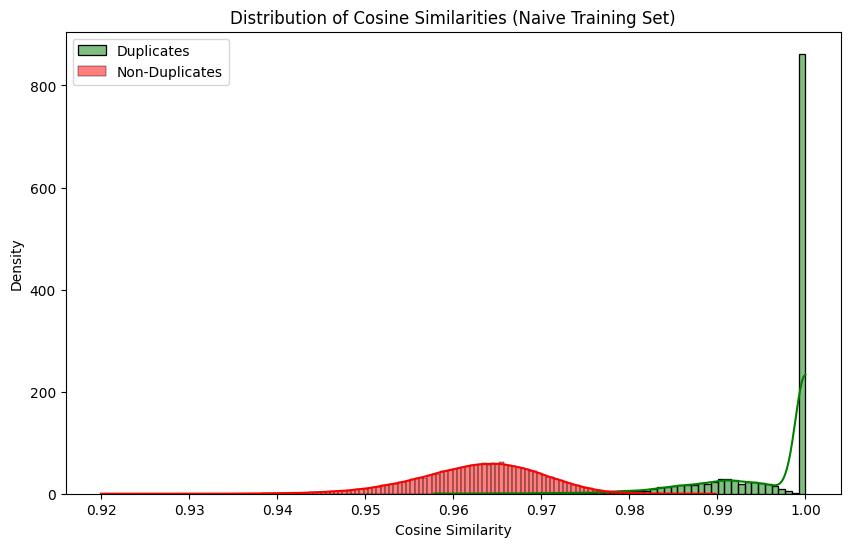

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a lookup dictionary for training embeddings {id: vector}
# Note: Using train_emb_df instead of val_emb_df
train_emb_id_map = {idx: i for i, idx in enumerate(train_emb_df['id'].values)}
train_embeddings_array = train_emb_df.drop(columns=['id']).values

def get_pair_sims(pairs_df, embeddings, id_map):
    sims = []
    for _, row in pairs_df.iterrows():
        id1, id2 = row['id1'], row['id2']
        if id1 in id_map and id2 in id_map:
            v1 = embeddings[id_map[id1]]
            v2 = embeddings[id_map[id2]]
            sims.append(cosine_sim(v1, v2))
    return sims

# 2. Compute similarities for the training splits
# Using dup_train and ndup_train created in the Naive split logic
dup_sims_train = get_pair_sims(dup_train, train_embeddings_array, train_emb_id_map)
ndup_sims_train = get_pair_sims(ndup_train, train_embeddings_array, train_emb_id_map)

# 3. Plotting results for Training Set
plt.figure(figsize=(10, 6))
sns.histplot(dup_sims_train, color='green', label='Duplicates', kde=True, stat='density', alpha=0.5)
sns.histplot(ndup_sims_train, color='red', label='Non-Duplicates', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Cosine Similarities (Naive Training Set)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.show()

In [53]:


print(f"Re-verified Naive Validation Counts:")
print(f"- Duplicates: {len(dup_val)}")
print(f"- Non-duplicates: {len(ndup_val)}")

# 2. Check alignment with validation embeddings generated earlier
val_emb_ids = set(val_emb_df['id'].unique())
present_dup = dup_val[dup_val['id1'].isin(val_emb_ids) & dup_val['id2'].isin(val_emb_ids)]
present_ndup = ndup_val[ndup_val['id1'].isin(val_emb_ids) & ndup_val['id2'].isin(val_emb_ids)]

print(f"\nPairs fully present in validation embeddings:")
print(f"- Duplicates: {len(present_dup)}")
print(f"- Non-duplicates: {len(present_ndup)}")

Re-verified Naive Validation Counts:
- Duplicates: 217
- Non-duplicates: 2162

Pairs fully present in validation embeddings:
- Duplicates: 217
- Non-duplicates: 2162


In [55]:
from sklearn.metrics import classification_report, confusion_matrix

val_emb_id_map = {idx: i for i, idx in enumerate(val_emb_df['id'].values)}
val_embeddings_array = val_emb_df.drop(columns=['id']).values

dup_sims_val = get_pair_sims(dup_val, val_embeddings_array, val_emb_id_map)
ndup_sims_val = get_pair_sims(ndup_val, val_embeddings_array, val_emb_id_map)

y_true = [1] * len(dup_sims_val) + [0] * len(ndup_sims_val)
y_sims = dup_sims_val + ndup_sims_val

# 3. Iterate through thresholds
thresholds = [0.95, 0.96, 0.97, 0.98,0.99]

for threshold in thresholds:
    y_pred = [1 if sim >= threshold else 0 for sim in y_sims]

    print(f"--- Corrected Validation Performance (Threshold: {threshold}) ---")
    print(classification_report(y_true, y_pred, target_names=['Non-Duplicate', 'Duplicate']))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(f"TP: {cm[1,1]} | FN: {cm[1,0]}")
    print(f"FP: {cm[0,1]} | TN: {cm[0,0]}")
    print("-" * 30)

--- Corrected Validation Performance (Threshold: 0.95) ---
               precision    recall  f1-score   support

Non-Duplicate       1.00      0.05      0.09      2162
    Duplicate       0.10      1.00      0.17       217

     accuracy                           0.13      2379
    macro avg       0.55      0.52      0.13      2379
 weighted avg       0.92      0.13      0.09      2379

Confusion Matrix:
TP: 217 | FN: 0
FP: 2064 | TN: 98
------------------------------
--- Corrected Validation Performance (Threshold: 0.96) ---
               precision    recall  f1-score   support

Non-Duplicate       1.00      0.31      0.48      2162
    Duplicate       0.13      1.00      0.23       217

     accuracy                           0.38      2379
    macro avg       0.56      0.66      0.35      2379
 weighted avg       0.92      0.38      0.45      2379

Confusion Matrix:
TP: 217 | FN: 0
FP: 1486 | TN: 676
------------------------------
--- Corrected Validation Performance (Threshold: 